## Kaggle Login

Install kagglehub first

In [1]:
%pip install kagglehub

Note: you may need to restart the kernel to use updated packages.


In [2]:
import kagglehub
kagglehub.login()

## Downloading the dataset

In [3]:
import os
path = kagglehub.competition_download('nfl-big-data-bowl-2026-prediction')
print("path:", path)
print("contents:", os.listdir(path))

path: C:\Users\sheen\.cache\kagglehub\competitions\nfl-big-data-bowl-2026-prediction
contents: ['kaggle_evaluation', 'test.csv', 'test_input.csv', 'train']


# EDA

## 0 - Setup

In [4]:
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation

pd.set_option("display.max_columns", 50)
plt.rcParams["figure.figsize"] = (10, 6)

DATA_DIR = r"C:\Users\sheen\.cache\kagglehub\competitions\nfl-big-data-bowl-2026-prediction\train"
CACHE_DIR = r"./cache" # parquet cache to avoid re-parsing CSVs every run
os.makedirs(CACHE_DIR, exist_ok=True)

FIELD_LENGTH = 120.0 # in yards
FIELD_WIDTH = 53.3 # in yards

## 1 - Load + concatenate weekly files (with parquet caching)

In [5]:
def load_weekly(pattern: str, cache_name: str) -> pd.DataFrame:
    """Load all weekly CSVs matching `pattern`, concat, cache as parquet."""
    cache_path = os.path.join(CACHE_DIR, cache_name)
    if os.path.exists(cache_path):
        print(f"Loading cached {cache_path}")
        return pd.read_parquet(cache_path)

    files = sorted(glob.glob(os.path.join(DATA_DIR, pattern)))
    if not files:
        raise FileNotFoundError(f"No files matched {pattern} in {DATA_DIR}")

    dfs = []
    for f in files:
        week = os.path.basename(f)
        print(f"Loading {week} ...")
        df = pd.read_csv(f)
        df["week_file"] = week
        dfs.append(df)

    out = pd.concat(dfs, ignore_index=True)
    out.to_parquet(cache_path, index=False)
    print(f"Cached to {cache_path} ({len(out):,} rows)")
    return out


input_df = load_weekly("input_2023_w*.csv", "input.parquet")
output_df = load_weekly("output_2023_w*.csv", "output.parquet")

print(input_df.shape, output_df.shape)
print(input_df.dtypes)

Loading cached ./cache\input.parquet
Loading cached ./cache\output.parquet
(4880579, 24) (562936, 7)
game_id                       int64
play_id                       int64
player_to_predict              bool
nfl_id                        int64
frame_id                      int64
play_direction               object
absolute_yardline_number      int64
player_name                  object
player_height                object
player_weight                 int64
player_birth_date            object
player_position              object
player_side                  object
player_role                  object
x                           float64
y                           float64
s                           float64
a                           float64
dir                         float64
o                           float64
num_frames_output             int64
ball_land_x                 float64
ball_land_y                 float64
week_file                    object
dtype: object


## 2 - Schema / join sanity checks

In [6]:
def sanity_checks(input_df: pd.DataFrame, output_df: pd.DataFrame) -> None:
    keys_in = input_df[["game_id", "play_id", "nfl_id"]].drop_duplicates()
    keys_out = output_df[["game_id", "play_id", "nfl_id"]].drop_duplicates()

    # a) every output player-play should exist in input
    merged = keys_out.merge(keys_in, how="left", indicator=True)
    missing_in_input = merged["_merge"].eq("right_only").sum()
    print(f"Output rows with no matching input player-play: {missing_in_input}")

    # b) players marked player_to_predict == True in input should all appear in output
    predict_keys = (
        input_df.loc[input_df["player_to_predict"], ["game_id", "play_id", "nfl_id"]]
        .drop_duplicates()
    )
    predict_vs_out = predict_keys.merge(keys_out, how="left", indicator=True)
    print(f"player_to_predict rows missing from output: "
          f"{(predict_vs_out['_merge'] == 'left_only').sum()} / {len(predict_keys):,}")

    # c) frame_id continuity in output: 1..num_frames_output per player-play
    num_frames = (
        input_df[["game_id", "play_id", "nfl_id", "num_frames_output"]]
        .drop_duplicates()
    )
    frame_counts = (
        output_df.groupby(["game_id", "play_id", "nfl_id"])["frame_id"]
        .agg(["count", "max"])
        .reset_index()
    )
    check = frame_counts.merge(num_frames, on=["game_id", "play_id", "nfl_id"], how="left")
    mismatch = check[(check["count"] != check["num_frames_output"]) |
                      (check["max"] != check["num_frames_output"])]
    print(f"Player-plays with frame_id count/max mismatch vs num_frames_output: "
          f"{len(mismatch)} / {len(check):,}")

    # d) coordinate range sanity
    for col_df, name in [(input_df, "input"), (output_df, "output")]:
        x_bad = ((col_df["x"] < -2) | (col_df["x"] > FIELD_LENGTH + 2)).sum() # add buffer/tolerance of ±2
        y_bad = ((col_df["y"] < -2) | (col_df["y"] > FIELD_WIDTH + 2)).sum() # add buffer/tolerance of ±2
        print(f"[{name}] x out of [0,{FIELD_LENGTH}] (±2 buffer): {x_bad}, "
              f"y out of [0,{FIELD_WIDTH}] (±2 buffer): {y_bad}")

    # e) duplicate rows
    dup_in = input_df.duplicated(subset=["game_id", "play_id", "nfl_id", "frame_id"]).sum()
    dup_out = output_df.duplicated(subset=["game_id", "play_id", "nfl_id", "frame_id"]).sum()
    print(f"Duplicate (game,play,nfl,frame) rows -> input: {dup_in}, output: {dup_out}")

    # f) frame-to-frame teleport check (large jumps that suggest data errors)
    tmp = output_df.sort_values(["game_id", "play_id", "nfl_id", "frame_id"]).copy()
    tmp["dx"] = tmp.groupby(["game_id", "play_id", "nfl_id"])["x"].diff()
    tmp["dy"] = tmp.groupby(["game_id", "play_id", "nfl_id"])["y"].diff()
    tmp["step_dist"] = np.sqrt(tmp["dx"] ** 2 + tmp["dy"] ** 2)

    # >1.5 yards in 1/10s = 15 yd/s, near the fastest humans ever recorded -> suspicious
    suspicious = tmp["step_dist"] > 1.5
    print(f"Frame-to-frame steps > 1.5 yd (15 yd/s): {suspicious.sum()} "
          f"({suspicious.mean()*100:.3f}% of steps)")


sanity_checks(input_df, output_df)

Output rows with no matching input player-play: 0
player_to_predict rows missing from output: 0 / 46,045
Player-plays with frame_id count/max mismatch vs num_frames_output: 0 / 46,045
[input] x out of [0,120.0] (±2 buffer): 0, y out of [0,53.3] (±2 buffer): 0
[output] x out of [0,120.0] (±2 buffer): 0, y out of [0,53.3] (±2 buffer): 0
Duplicate (game,play,nfl,frame) rows -> input: 0, output: 0
Frame-to-frame steps > 1.5 yd (15 yd/s): 5 (0.001% of steps)


## 3 - Normalize play direction so every play "attacks" the same way

In [7]:
def normalize_direction(df: pd.DataFrame) -> pd.DataFrame:
    """Flip x, y, o, dir for plays moving left so all plays go left->right.

    This matters a lot for a model that shares weights across plays.
    """
    df = df.copy()
    left = df["play_direction"] == "left"

    df.loc[left, "x"] = FIELD_LENGTH - df.loc[left, "x"]
    df.loc[left, "y"] = FIELD_WIDTH - df.loc[left, "y"]

    for angle_col in ["o", "dir"]:
        if angle_col in df.columns:
            df.loc[left, angle_col] = (df.loc[left, angle_col] + 180) % 360

    return df


input_norm = normalize_direction(input_df)
if "ball_land_x" in input_norm.columns:
    left = input_df["play_direction"] == "left"
    input_norm.loc[left, "ball_land_x"] = FIELD_LENGTH - input_norm.loc[left, "ball_land_x"]
    input_norm.loc[left, "ball_land_y"] = FIELD_WIDTH - input_norm.loc[left, "ball_land_y"]

# output needs the same flip, joined on play_direction from input
play_dir_lookup = input_df[["game_id", "play_id", "play_direction"]].drop_duplicates()
output_norm = output_df.merge(play_dir_lookup, on=["game_id", "play_id"], how="left")
output_norm = normalize_direction(output_norm)


# unflip and reverse the predictions. run this last.
def unflip_predictions(pred_df: pd.DataFrame, play_dir_lookup: pd.DataFrame) -> pd.DataFrame:
    """Reverse normalize_direction() on model predictions before submission.

    pred_df must have game_id, play_id, x, y (predictions made in normalized
    space). play_dir_lookup must have game_id, play_id, play_direction
    (the ORIGINAL, pre-normalization play_direction for each play).

    This is a 180-degree rotation (x -> FIELD_LENGTH - x, y -> FIELD_WIDTH - y),
    which is its own inverse -- applying it twice returns the original values.
    So unflipping reuses normalize_direction() directly rather than needing
    separate logic.
    """
    merged = pred_df.merge(play_dir_lookup, on=["game_id", "play_id"], how="left")
    if merged["play_direction"].isna().any():
        n_missing = merged["play_direction"].isna().sum()
        raise ValueError(
            f"{n_missing} prediction rows have no matching play_direction — "
            "check the join keys before submitting."
        )
    return normalize_direction(merged).drop(columns=["play_direction"])

# lil sanity check: flip then unflip should return the original x, y exactly.
def _test_flip_unflip_roundtrip(input_df: pd.DataFrame) -> None:
    sample = input_df[["game_id", "play_id", "nfl_id", "x", "y", "play_direction"]].head(5000).copy()
    dir_lookup = sample[["game_id", "play_id", "play_direction"]].drop_duplicates()

    flipped = normalize_direction(sample)
    roundtrip = unflip_predictions(
        flipped[["game_id", "play_id", "nfl_id", "x", "y"]], dir_lookup
    )

    x_match = np.allclose(sample["x"].values, roundtrip["x"].values, atol=1e-9)
    y_match = np.allclose(sample["y"].values, roundtrip["y"].values, atol=1e-9)
    assert x_match and y_match, "Flip -> unflip round-trip did NOT recover original x, y!"
    print("Flip/unflip round-trip check passed: original == unflip(flip(original))")


_test_flip_unflip_roundtrip(input_df)


Flip/unflip round-trip check passed: original == unflip(flip(original))


## 4 - ***num_frames_output*** distribution (our prediction horizon)

count    14108.000000
mean        11.366601
std          5.147501
min          5.000000
25%          8.000000
50%         10.000000
75%         13.000000
max         94.000000
Name: num_frames_output, dtype: float64


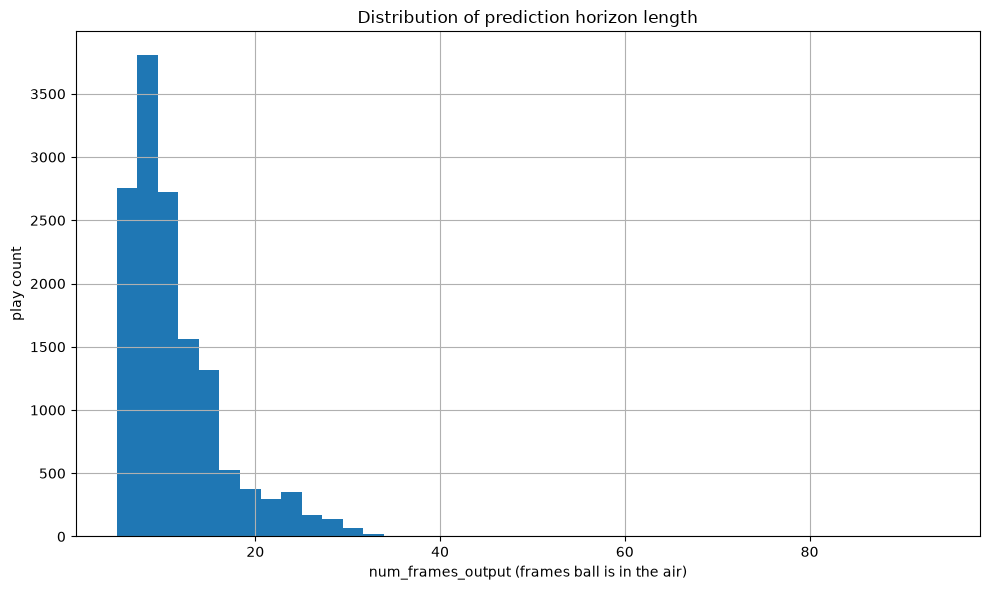

In [8]:
horizon = (
    input_df[["game_id", "play_id", "num_frames_output"]]
    .drop_duplicates()["num_frames_output"]
)
print(horizon.describe())

fig, ax = plt.subplots()
horizon.hist(bins=40, ax=ax)
ax.set_xlabel("num_frames_output (frames ball is in the air)")
ax.set_ylabel("play count")
ax.set_title("Distribution of prediction horizon length")
plt.tight_layout()
plt.savefig(os.path.join(CACHE_DIR, "horizon_hist.png"), dpi=120)
plt.show()

## 5 - Displacement by ***player_role***

During the time the ball is in the air, how much do different types of players actually move?

**net_displacement** = *How far away did they end up from where they started?*

**path_length** = *How much total ground did they travel?*

                   net_displacement                                          \
                              count      mean       std       min       25%   
player_role                                                                   
Defensive Coverage          31937.0  5.734746  4.568965  0.022361  2.650887   
Targeted Receiver           14108.0  6.074466  5.063940  0.010000  2.821790   

                                                  path_length            \
                         50%       75%        max       count      mean   
player_role                                                               
Defensive Coverage  4.387824  7.252069  30.410769     31937.0  5.931614   
Targeted Receiver   4.673264  7.434904  32.485758     14108.0  6.173295   

                                                                      \
                         std       min       25%       50%       75%   
player_role                                                            
Defensive Co

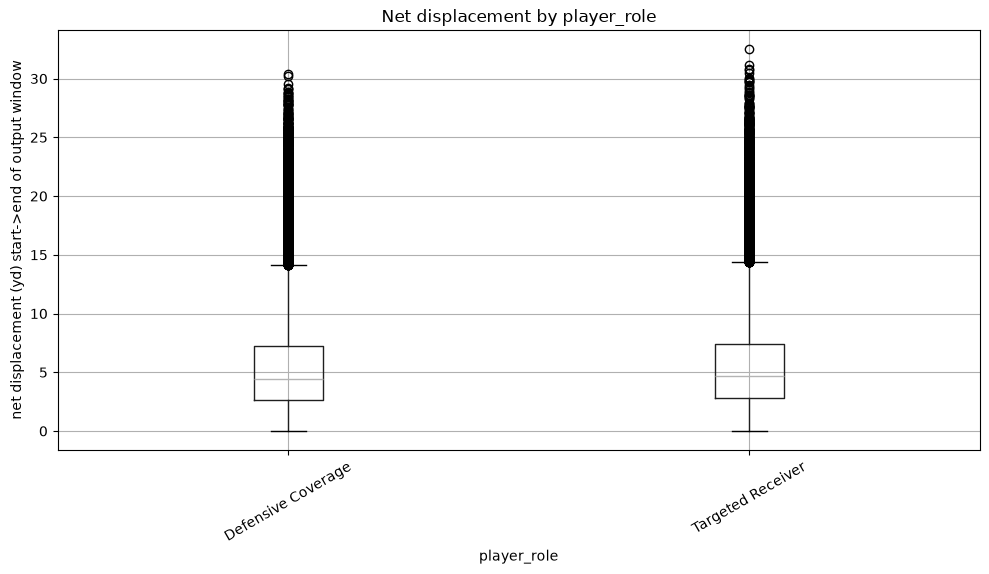

In [9]:
def displacement_by_role(input_df: pd.DataFrame, output_norm: pd.DataFrame) -> pd.DataFrame:
    role_lookup = (
        input_df[["game_id", "play_id", "nfl_id", "player_role", "player_position"]]
        .drop_duplicates()
    )

    traj = output_norm.sort_values(["game_id", "play_id", "nfl_id", "frame_id"])

    # group by the SAME 3 keys for both net_disp and total_path so their
    # indexes line up -- player_role gets attached afterward via merge,
    # not included in the groupby (it doesn't vary within a player-play anyway)
    grp = traj.groupby(["game_id", "play_id", "nfl_id"])
    first = grp.first()
    last = grp.last()

    net_disp = np.sqrt((last["x"] - first["x"]) ** 2 + (last["y"] - first["y"]) ** 2)
    net_disp.name = "net_displacement"

    # total path length (sum of frame-to-frame steps)
    traj["dx"] = traj.groupby(["game_id", "play_id", "nfl_id"])["x"].diff()
    traj["dy"] = traj.groupby(["game_id", "play_id", "nfl_id"])["y"].diff()
    traj["step"] = np.sqrt(traj["dx"] ** 2 + traj["dy"] ** 2)
    total_path = traj.groupby(["game_id", "play_id", "nfl_id"])["step"].sum()
    total_path.name = "path_length"

    summary = pd.concat([net_disp, total_path], axis=1).reset_index()
    summary = summary.merge(role_lookup, on=["game_id", "play_id", "nfl_id"], how="left")

    return summary


disp_summary = displacement_by_role(input_df, output_norm)
print(disp_summary.groupby("player_role")[["net_displacement", "path_length"]].describe())

fig, ax = plt.subplots()
disp_summary.boxplot(column="net_displacement", by="player_role", ax=ax, rot=30)
ax.set_ylabel("net displacement (yd) start->end of output window")
plt.suptitle("")
plt.title("Net displacement by player_role")
plt.tight_layout()
plt.savefig(os.path.join(CACHE_DIR, "displacement_by_role.png"), dpi=120)
plt.show()

### Findings
Average **net_displacement** for each player role:

- Defensive Coverage: **5.7 yards**
- Targeted Receiver: **6.1 yards**

Average **path_length** for each player role:

- Defensive Coverage: **6 yards**
- Targeted Reciever: **6.2 yards**

## 6 - Distance-to-ball-landing-spot over time, by role

As the ball gets closer to where it's going to land, 

do the receiver and defender **actually move toward** that landing spot?

How do players move relative to the ball's eventual landing location?

**Calculation**:

How many yards away is the receiver from that landing spot?

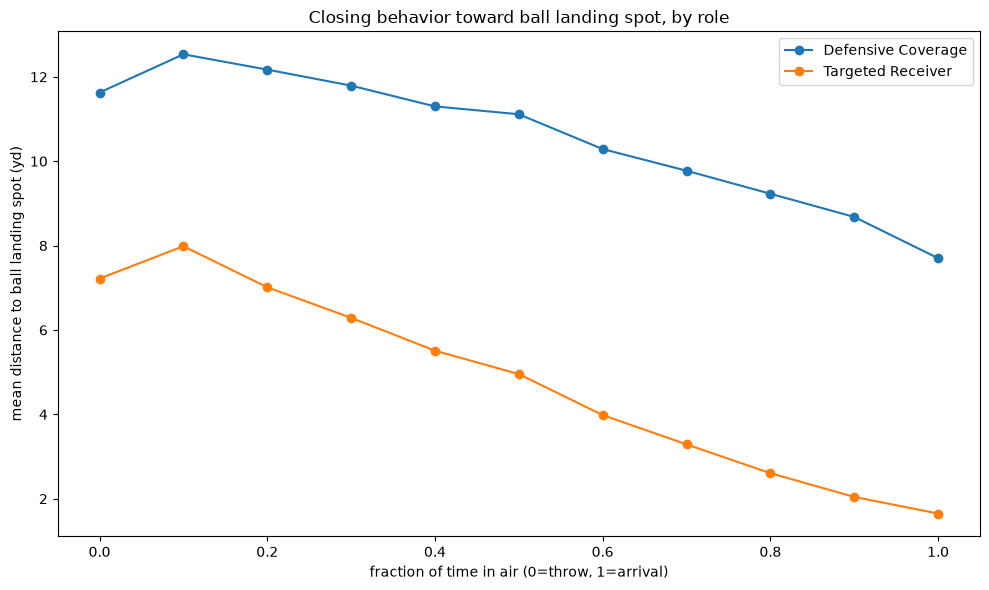

In [10]:
def distance_to_landing_over_time(input_norm: pd.DataFrame, output_norm: pd.DataFrame) -> pd.DataFrame:

    ball_lookup = (
        input_norm[["game_id", "play_id", "ball_land_x", "ball_land_y"]]
        .drop_duplicates()
    )
    role_lookup = (
        input_norm[["game_id", "play_id", "nfl_id", "player_role"]]
        .drop_duplicates()
    )
 
    traj = output_norm.merge(ball_lookup, on=["game_id", "play_id"], how="left")
    traj = traj.merge(role_lookup, on=["game_id", "play_id", "nfl_id"], how="left")
 
    traj["dist_to_land"] = np.sqrt(
        (traj["x"] - traj["ball_land_x"]) ** 2 + (traj["y"] - traj["ball_land_y"]) ** 2
    )
 
    # normalizing frame_id to a fraction of each play's horizon so plays of different lengths can be averaged together
    traj["frame_frac"] = traj.groupby(["game_id", "play_id", "nfl_id"])["frame_id"].transform(
        lambda s: (s - 1) / max(s.max() - 1, 1)
    )
    traj["frame_bucket"] = (traj["frame_frac"] * 10).round().astype(int)  # 0..10
 
    curve = (
        traj.groupby(["player_role", "frame_bucket"])["dist_to_land"]
        .mean()
        .reset_index()
    )
    return curve
 
 
dist_curve = distance_to_landing_over_time(input_norm, output_norm)
 
fig, ax = plt.subplots()
for role, sub in dist_curve.groupby("player_role"):
    ax.plot(sub["frame_bucket"] / 10.0, sub["dist_to_land"], marker="o", label=role)
ax.set_xlabel("fraction of time in air (0=throw, 1=arrival)")
ax.set_ylabel("mean distance to ball landing spot (yd)")
ax.set_title("Closing behavior toward ball landing spot, by role")
ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(CACHE_DIR, "dist_to_landing_by_role.png"), dpi=120)
plt.show()

### Findings
<u>Targeted Receivers</u> tend to be **closer** to the eventual landing spot than the defenders.

## 7 - Baseline error floor: constant-velocity extrapolation

Before we build a fancy ML model, how well can a really simple model already do?

*Here's the level of performance we get from this basic approach. A useful ML model should ideally do better.*

Quantifying this BEFORE building anything fancier. It tells us how much of the problem is ***"easy"*** physics vs. genuine decision-making.

The formula: **Starting position** + **movement** × **time** = **predicted future position**

Constant-velocity baseline mean position error (yd) by role:
                        mean    median       std
player_role                                     
Defensive Coverage  1.521097  0.796939  2.059224
Targeted Receiver   1.129392  0.559529  1.641422


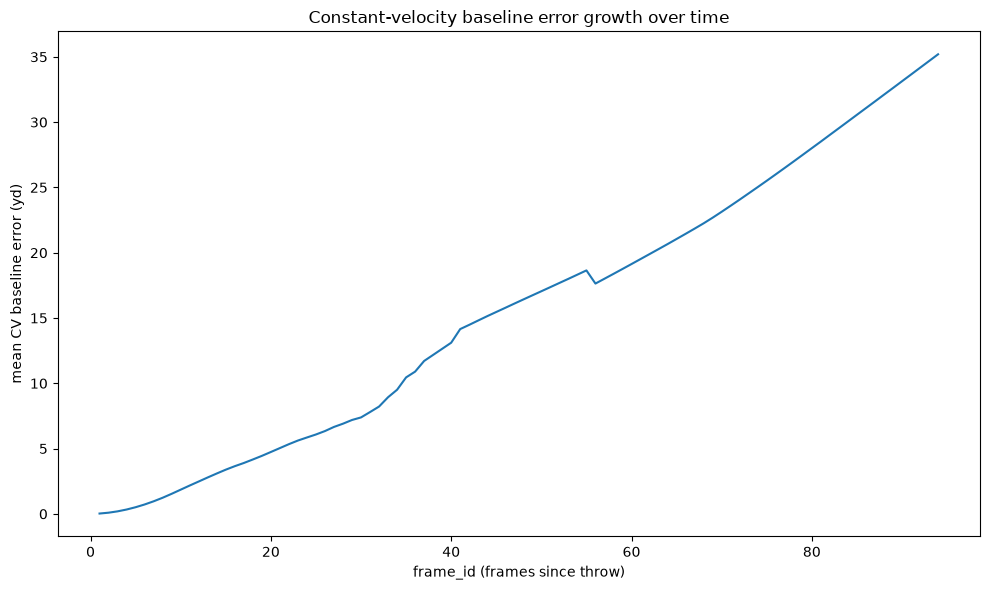

In [11]:
def constant_velocity_baseline(input_norm: pd.DataFrame, output_norm: pd.DataFrame) -> pd.DataFrame:
    """For each player-play, extrapolate x,y forward using last-frame s, dir."""
    last_input = (
        input_norm.sort_values(["game_id", "play_id", "nfl_id", "frame_id"])
        .groupby(["game_id", "play_id", "nfl_id"])
        .last()
        .reset_index()
    )

    dir_rad = np.deg2rad(last_input["dir"])
    last_input["vx"] = last_input["s"] * np.sin(dir_rad)
    last_input["vy"] = last_input["s"] * np.cos(dir_rad)
 
    traj = output_norm.merge(
        last_input[["game_id", "play_id", "nfl_id", "x", "y", "vx", "vy"]],
        on=["game_id", "play_id", "nfl_id"],
        suffixes=("", "_start"),
    )
    traj["t"] = traj["frame_id"] * 0.1  # seconds since throw (frame 1 = 0.1s)
    traj["pred_x"] = traj["x_start"] + traj["vx"] * traj["t"]
    traj["pred_y"] = traj["y_start"] + traj["vy"] * traj["t"]
 
    traj["err"] = np.sqrt((traj["x"] - traj["pred_x"]) ** 2 + (traj["y"] - traj["pred_y"]) ** 2)
    return traj
 
 
cv_baseline = constant_velocity_baseline(input_norm, output_norm)
print("Constant-velocity baseline mean position error (yd) by role:")
role_lookup = input_norm[["game_id", "play_id", "nfl_id", "player_role"]].drop_duplicates()
cv_baseline = cv_baseline.merge(role_lookup, on=["game_id", "play_id", "nfl_id"], how="left")
print(cv_baseline.groupby("player_role")["err"].agg(["mean", "median", "std"]))
 
# error should grow with frame_id. just worth plotting
err_by_frame = cv_baseline.groupby("frame_id")["err"].mean()
fig, ax = plt.subplots()
err_by_frame.plot(ax=ax)
ax.set_xlabel("frame_id (frames since throw)")
ax.set_ylabel("mean CV baseline error (yd)")
ax.set_title("Constant-velocity baseline error growth over time")
plt.tight_layout()
plt.savefig(os.path.join(CACHE_DIR, "cv_baseline_error.png"), dpi=120)
plt.show()

## 8 - Single-play trajectory plot / animation

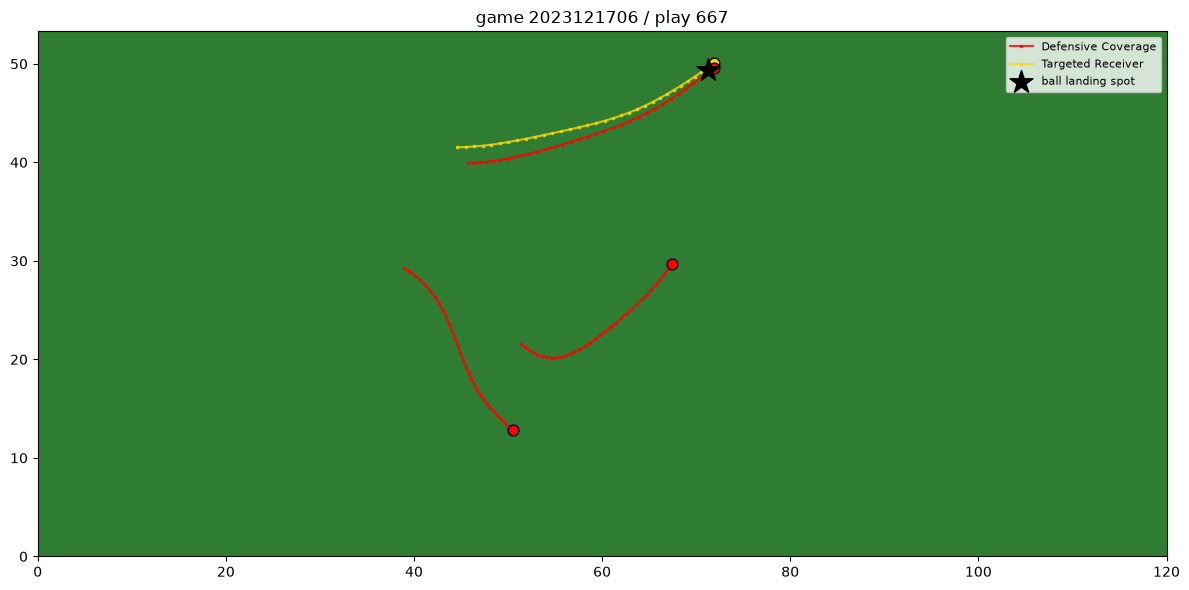

In [12]:
def plot_play(game_id: int, play_id: int, input_df: pd.DataFrame, output_norm: pd.DataFrame,
              save_path: str | None = None) -> None:
    inp = input_df[(input_df.game_id == game_id) & (input_df.play_id == play_id)]
    out = output_norm[(output_norm.game_id == game_id) & (output_norm.play_id == play_id)]

    role_lookup = inp[["nfl_id", "player_role", "player_side"]].drop_duplicates().set_index("nfl_id")
    ball_land = inp[["ball_land_x", "ball_land_y"]].iloc[0]

    fig, ax = plt.subplots(figsize=(12, 6))
    ax.set_xlim(0, FIELD_LENGTH)
    ax.set_ylim(0, FIELD_WIDTH)
    ax.set_facecolor("#2e7d32")
    ax.set_title(f"game {game_id} / play {play_id}")

    color_map = {
        "Targeted Receiver": "gold",
        "Defensive Coverage": "red",
        "Passer": "white",
        "Other Route Runner": "lightblue",
    }

    for nfl_id, grp in out.groupby("nfl_id"):
        grp = grp.sort_values("frame_id")
        role = role_lookup.loc[nfl_id, "player_role"] if nfl_id in role_lookup.index else "Other"
        c = color_map.get(role, "gray")
        ax.plot(grp["x"], grp["y"], marker=".", markersize=3, color=c, alpha=0.8, label=role)
        ax.scatter(grp["x"].iloc[-1], grp["y"].iloc[-1], color=c, edgecolor="black", s=60, zorder=5)

    ax.scatter([ball_land["ball_land_x"]], [ball_land["ball_land_y"]],
               marker="*", s=300, color="black", label="ball landing spot", zorder=6)

    handles, labels = ax.get_legend_handles_labels()
    uniq = dict(zip(labels, handles))
    ax.legend(uniq.values(), uniq.keys(), loc="upper right", fontsize=8)

    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=120)
    plt.show()


def animate_play(game_id: int, play_id: int, input_df: pd.DataFrame, output_norm: pd.DataFrame,
                  save_path: str = None):
    """Frame-by-frame animation; save_path e.g. 'play.gif' (needs pillow)."""
    out = output_norm[(output_norm.game_id == game_id) & (output_norm.play_id == play_id)]
    inp = input_df[(input_df.game_id == game_id) & (input_df.play_id == play_id)]
    role_lookup = inp[["nfl_id", "player_role"]].drop_duplicates().set_index("nfl_id")
    ball_land = inp[["ball_land_x", "ball_land_y"]].iloc[0]

    color_map = {
        "Targeted Receiver": "gold",
        "Defensive Coverage": "red",
        "Passer": "white",
        "Other Route Runner": "lightblue",
    }

    frames = sorted(out["frame_id"].unique())
    fig, ax = plt.subplots(figsize=(12, 6))

    def draw(frame_id):
        ax.clear()
        ax.set_xlim(0, FIELD_LENGTH)
        ax.set_ylim(0, FIELD_WIDTH)
        ax.set_facecolor("#2e7d32")
        ax.set_title(f"game {game_id} / play {play_id} — frame {frame_id}")
        snap = out[out.frame_id == frame_id]
        for _, row in snap.iterrows():
            role = role_lookup.loc[row.nfl_id, "player_role"] if row.nfl_id in role_lookup.index else "Other"
            ax.scatter(row.x, row.y, color=color_map.get(role, "gray"), s=80, edgecolor="black")
        ax.scatter([ball_land["ball_land_x"]], [ball_land["ball_land_y"]],
                   marker="*", s=300, color="black")

    anim = FuncAnimation(fig, draw, frames=frames, interval=100)
    if save_path:
        anim.save(save_path, writer="pillow", fps=10)
    return anim


# Example usage once data is loaded — pick a play with a reasonably long horizon:
sample = (
    input_df[["game_id", "play_id", "num_frames_output"]]
    .drop_duplicates()
    .sort_values("num_frames_output", ascending=False)
    .iloc[10]  # skip the very longest outlier, grab something representative
)
plot_play(int(sample.game_id), int(sample.play_id), input_norm, output_norm,
          save_path=os.path.join(CACHE_DIR, "sample_play.png"))

## 9 - Weekly distribution shift check

 (for our held-out validation split)

    week  n_plays  mean_speed  mean_yardline
0      1      748    3.041966      60.343049
1      2      777    2.931589      59.833332
2      3      823    2.964380      60.791367
3      4      710    3.026389      60.178827
4      5      677    2.991852      62.459127
5      6      715    2.998998      60.968435
6      7      646    2.969080      59.620350
7      8      765    3.021164      61.374555
8      9      656    3.061792      61.067430
9     10      673    3.058637      59.257336
10    11      657    3.030971      58.773817
11    12      755    3.048639      60.783275
12    13      622    3.075218      61.350123
13    14      738    3.048283      60.997289
14    15      702    3.058845      61.168427
15    16      822    3.041660      57.851250
16    17      734    3.014160      62.147099
17    18      686    2.977406      61.242706


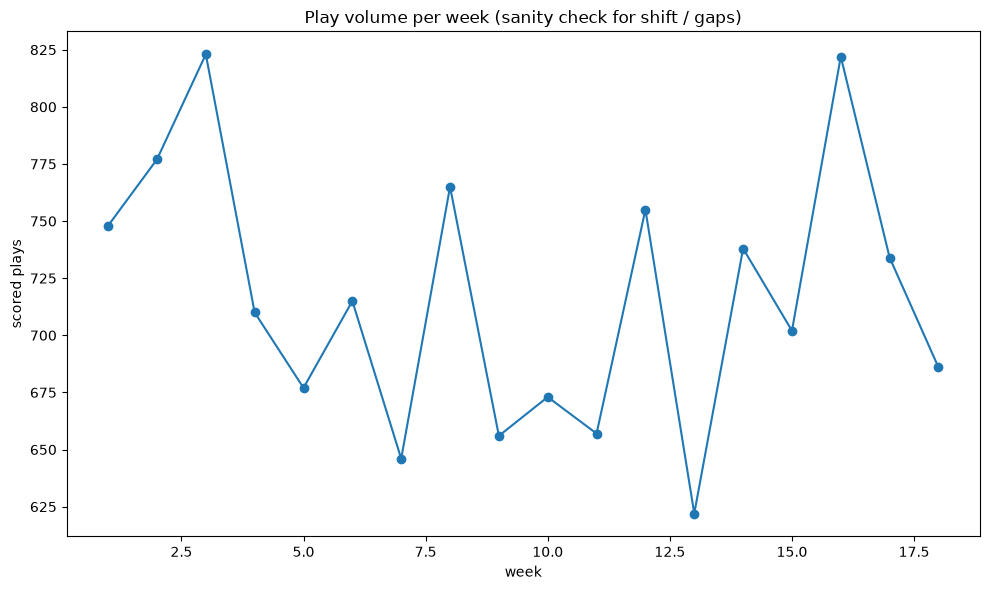


Done. PNGs written to ./cache


In [13]:
def week_of(fname: str) -> int:
    return int(fname.split("_w")[-1].split(".")[0])


input_df["week"] = input_df["week_file"].apply(week_of)
weekly_stats = input_df.groupby("week").agg(
    n_plays=("play_id", "nunique"),
    mean_speed=("s", "mean"),
    mean_yardline=("absolute_yardline_number", "mean"),
).reset_index()
print(weekly_stats)

fig, ax = plt.subplots()
ax.plot(weekly_stats["week"], weekly_stats["n_plays"], marker="o")
ax.set_xlabel("week")
ax.set_ylabel("scored plays")
ax.set_title("Play volume per week (sanity check for shift / gaps)")
plt.tight_layout()
plt.savefig(os.path.join(CACHE_DIR, "weekly_play_volume.png"), dpi=120)
plt.show()

print("\nDone. PNGs written to", CACHE_DIR)